[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammad-zainal-muttaqin/NulisBuku/blob/main/website/notebooks/ch08.ipynb)

Notebook Bab 8 ini punya dua bagian. Bagian **Demo** tinggal Anda jalankan lalu amati keluarannya; bagian **Mini Project** berisi soal dan data yang Anda kerjakan sendiri.

Reduksi dimensi memampatkan fitur. Kita memakai Optical Digits untuk melihat PCA sebagai kompresi linear, NMF sebagai faktor aditif pada data non-negatif, dan akurasi probe sebagai ukuran hilangnya informasi.


## Persiapan


In [1]:
import os
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA, NMF
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid')


from pathlib import Path
import json
import urllib.request
import urllib.parse

DATA_BASE_URL = 'https://raw.githubusercontent.com/muhammad-zainal-muttaqin/NulisBuku/main/website/notebooks/data/section1'


def section_data_dir(name):
    """Folder data Bagian 1: pakai salinan lokal bila ada; jika tidak (mis. di
    Google Colab), unduh berkas dari repo GitHub sesuai manifest."""
    for base in (Path('data/section1'), Path('../data/section1')):
        if (base / name).exists():
            return base / name
    cache = Path('_nb_data') / name
    if not (cache / 'manifest.json').exists():
        cache.mkdir(parents=True, exist_ok=True)
        base_url = DATA_BASE_URL + '/' + name
        manifest = json.loads(urllib.request.urlopen(base_url + '/manifest.json').read().decode('utf-8'))
        for rel in manifest:
            dest = cache / rel
            dest.parent.mkdir(parents=True, exist_ok=True)
            if not dest.exists():
                url = base_url + '/' + '/'.join(urllib.parse.quote(seg) for seg in rel.split('/'))
                urllib.request.urlretrieve(url, dest)
        (cache / 'manifest.json').write_text(json.dumps(manifest), encoding='utf-8')
    return cache


## Section 1 - Demo: Kompresi Optical Digits


## Data: citra digit 8x8 sebagai 64 fitur

Setiap digit direpresentasikan sebagai 64 hitungan piksel bernilai 0 sampai 16. Snapshot lokal memakai copy sklearn agar notebook cepat dan stabil secara offline.


In [2]:
DATA_DIR = section_data_dir('ch08_digits')
digits = pd.read_parquet(DATA_DIR / 'digits.parquet')
images = np.load(DATA_DIR / 'digits_images.npy')
stats = json.loads((DATA_DIR / 'verified_stats.json').read_text(encoding='utf-8'))

X = digits.drop(columns=['digit'])
y = digits['digit']
print(f"Rows in local sklearn snapshot: {stats['local_sklearn_rows']:,}")
print(f"UCI full archive instances listed on page: {stats['uci_page_instances']:,}")
print(f"Features: {stats['feature_count']} | pixel range: {stats['pixel_min']:.0f}..{stats['pixel_max']:.0f} | missing cells: {stats['missing_cells']}")
print('Class counts:', stats['class_counts'])
print('PCA components for 80/90/95% variance:', stats['pca_components_for_variance_thresholds'])


Rows in local sklearn snapshot: 1,797
UCI full archive instances listed on page: 5,620
Features: 64 | pixel range: 0..16 | missing cells: 0
Class counts: {'0': 178, '1': 182, '2': 177, '3': 183, '4': 181, '5': 182, '6': 181, '7': 179, '8': 174, '9': 180}
PCA components for 80/90/95% variance: {'0.8': {'components': 21, 'cumulative_variance': 0.80661732268226}, '0.9': {'components': 31, 'cumulative_variance': 0.9004642597586601}, '0.95': {'components': 40, 'cumulative_variance': 0.9507791125066465}}


## PCA 2D: bagus untuk melihat, belum tentu cukup untuk memprediksi

PCA mencari arah varians terbesar setelah standardisasi. Dua komponen pertama memberi peta visual, tetapi peta 2D ini sengaja sangat ringkas.


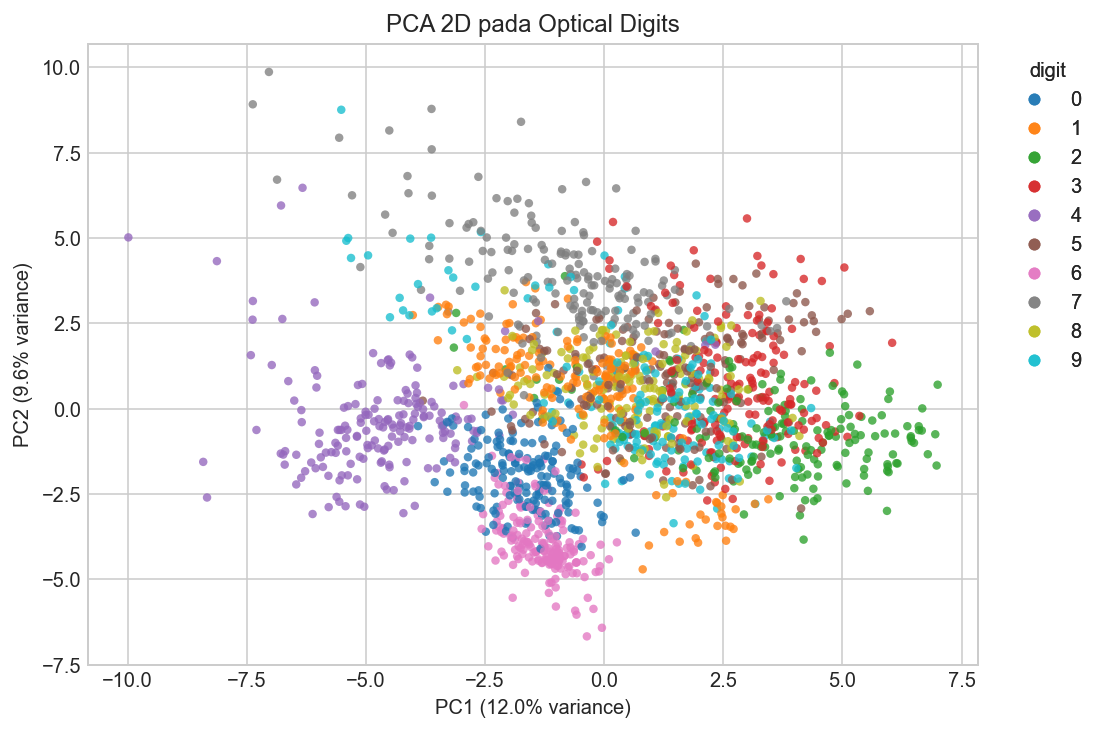

In [3]:
Xs = StandardScaler().fit_transform(X)
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
Z2 = pca2.fit_transform(Xs)

fig, ax = plt.subplots(figsize=(7, 5.2))
scatter = ax.scatter(Z2[:, 0], Z2[:, 1], c=y, cmap='tab10', s=18, alpha=0.78, linewidths=0)
ax.set_title('PCA 2D pada Optical Digits')
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%} variance)')
legend = ax.legend(*scatter.legend_elements(), title='digit', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.add_artist(legend)
plt.tight_layout()
plt.show()


## NMF: komponen aditif pada piksel non-negatif

Karena piksel bernilai non-negatif, NMF dapat langsung dipakai pada data mentah. Komponen NMF dapat dibaca sebagai pola bagian yang ditambahkan untuk merekonstruksi digit.


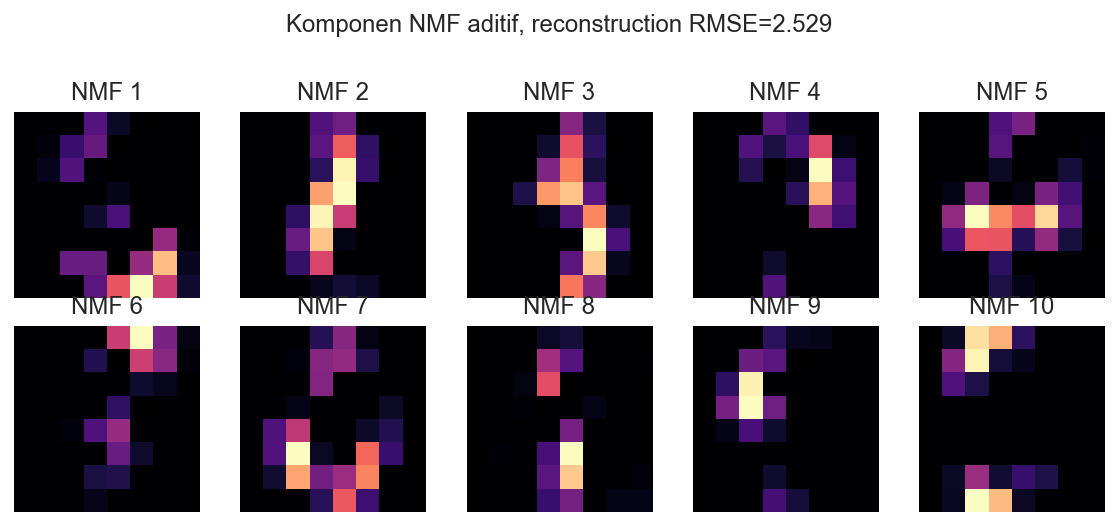

In [4]:
nmf = NMF(n_components=10, init='nndsvda', random_state=RANDOM_STATE, max_iter=1000)
W = nmf.fit_transform(X)
components = nmf.components_.reshape(10, 8, 8)
rmse = np.sqrt(np.mean((X.values - nmf.inverse_transform(W)) ** 2))

fig, axes = plt.subplots(2, 5, figsize=(8, 3.5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(components[i], cmap='magma')
    ax.set_title(f'NMF {i+1}')
    ax.axis('off')
fig.suptitle(f'Komponen NMF aditif, reconstruction RMSE={rmse:.3f}', y=1.03)
plt.tight_layout()
plt.show()


## Berapa banyak komponen cukup?

Untuk tugas prediksi, kita ukur kompresi memakai probe sederhana: Logistic Regression yang sama, dengan jumlah komponen PCA berbeda.


 components  mean_accuracy  std_accuracy
          2         0.5492        0.0129
          5         0.8114        0.0079
         10         0.8815        0.0138
         20         0.9488        0.0028
         30         0.9594        0.0078
         40         0.9683        0.0038
         64         0.9711        0.0037


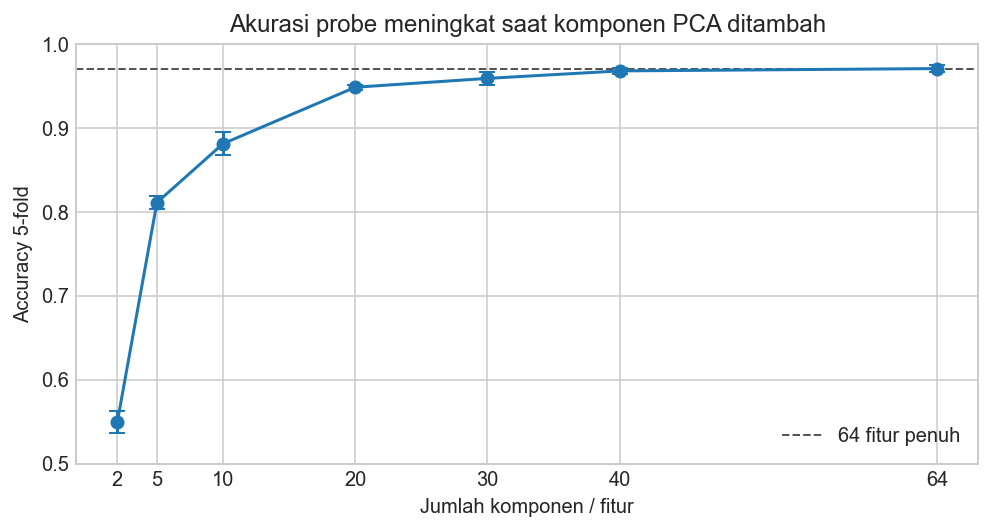

In [5]:
acc_df = pd.read_csv(DATA_DIR / 'pca_probe_accuracy.csv')
print(acc_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.errorbar(acc_df['components'], acc_df['mean_accuracy'], yerr=acc_df['std_accuracy'], marker='o', capsize=4)
ax.set_xlabel('Jumlah komponen / fitur')
ax.set_ylabel('Accuracy 5-fold')
ax.set_title('Akurasi probe meningkat saat komponen PCA ditambah')
ax.set_xticks(acc_df['components'])
ax.set_ylim(0.5, 1.0)
ax.axhline(acc_df.loc[acc_df['components'] == 64, 'mean_accuracy'].iloc[0], color='#555555', linestyle='--', linewidth=1, label='64 fitur penuh')
ax.legend()
plt.tight_layout()
plt.show()


>
> 🔎 **Amati.** Dua komponen PCA cukup membantu visualisasi, tetapi akurasi probe turun jauh karena banyak informasi digit hilang. Sekitar 20 sampai 40 komponen sudah mendekati performa 64 fitur penuh. NMF sah dipakai di sini karena piksel tidak negatif; komponennya lebih aditif, tetapi tetap bergantung pada jumlah komponen dan inisialisasi.


## Section 2 - Mini Project

## Soal

Gunakan dataset Optical Digits yang sama. Targetnya adalah `digit`.

Tugas:
1. Cari jumlah komponen PCA yang mencapai minimal 95% cumulative explained variance.
2. Bandingkan akurasi Logistic Regression pada fitur penuh, PCA 10 komponen, dan PCA pada ambang 95%.
3. Jelaskan apakah PCA 2D layak dipakai sebagai fitur prediktif atau hanya sebagai visualisasi.


In [6]:
# DATA AWAL (jangan diubah) - Optical Digits lokal.
Xm = X.copy()
ym = y.copy()
print('Data:', Xm.shape, '| kelas:', np.bincount(ym))


Data: (1797, 64) | kelas: [178 182 177 183 181 182 181 179 174 180]


In [7]:
# Kerjakan di sini.
# Petunjuk: PCA().fit(StandardScaler().fit_transform(Xm)).explained_variance_ratio_.cumsum()
